# 材料・化学の実験データをMLに使う前にやること
## 欠損・外れ値・単位不統一の実践的対処法

このノートブックは Zenn 記事「材料・化学の実験データをMLに使う前にやること」のコード確認用です。  
記事本文: `article.md` / 調査資料: `research.md`

### 扱うテーマ
1. **欠損値の扱い** — 測定値の欠損・条件変数の欠損・配合データの構造的ゼロ
2. **外れ値の検出と対処** — Isolation Forest、Winsorization、ロバスト回帰
3. **単位・表記の不統一** — Pint による単位変換、スケーラーの比較、CLR 変換

### 前提
- Python 3.8 以上
- 環境: `~/venvs/career-zenn`（Jupyter カーネル名: **Career Zenn**）
- 依存関係: `../requirements.txt` を参照
- 必要ライブラリ: `scikit-learn`, `numpy`, `pandas`, `matplotlib`, `seaborn`, `feature-engine`, `pint`, `pint-pandas`
- オプション: `rdkit`

---

## 共通セットアップ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 日本語フォント設定（macOS の場合）
plt.rcParams['font.family'] = 'Hiragino Sans'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

---
## 1. 欠損値の扱い

材料・化学の実験データで欠損が生じる主な原因は以下の3つ。

| 原因 | 例 |
|------|---------|
| 実験中断・機器エラー | サンプル破損、測定失敗 |
| BDL（検出限界以下） | 微量元素の濃度が機器の検出限界を下回る |
| 実験設計の違い | 複数データセットを統合した際の測定項目不一致 |

欠損への対処は「削除」か「補完」の2択だが、数十〜数百行しかない小データで削除を選ぶとサンプルの多様性が失われる。**原則として補完を選ぶ**。

また、欠損しているのが「**測定値**（硬度・導電率など）」か「**条件変数**（温度・時間など）」かによって対処が変わる。さらに配合データでは「**構造的ゼロ**（その材料を使わなかった）」と「**真の欠損**（使ったが記録がない）」を区別する必要がある。このノートブックでは3つのケースを順に扱う。

### 1-1. サンプルデータ作成

合金材料の実験データを想定したサンプルを生成する。  
特徴量：組成比（A成分）、焼成温度、硬度、導電率、引張強度の5列。  
導電率と引張強度に人工的に約15%の欠損を追加する（測定値の欠損を再現）。

In [2]:
n = 50

df = pd.DataFrame({
    'composition_A': np.random.uniform(0.1, 0.9, n),
    'temperature_K': np.random.uniform(400, 1200, n),
    'hardness':      np.random.uniform(100, 800, n),
    'conductivity':  np.random.uniform(1, 100, n),
    'tensile_strength': np.random.uniform(200, 1500, n),
})

# 欠損を追加
for col in ['conductivity', 'tensile_strength']:
    mask = np.random.rand(n) < 0.15
    df.loc[mask, col] = np.nan

print("データ形状:", df.shape)
print("\n欠損数:")
print(df.isnull().sum())
df.head(10)

データ形状: (50, 5)

欠損数:
composition_A       0
temperature_K       0
hardness            0
conductivity        8
tensile_strength    9
dtype: int64


,composition_A,temperature_K,hardness,conductivity,tensile_strength
0,0.399632,1175.667702,122.000430,90.918323,NaN
1,0.860571,1020.106259,545.487288,24.716627,309.381954
2,0.685595,1151.599153,320.049187,15.344592,410.117328
3,0.578927,1115.861880,455.999484,49.455823,1368.120445
4,0.224815,878.319983,735.296532,98.579395,988.357778
5,0.224796,1137.499388,274.504560,24.963472,211.956167
6,0.146467,470.794002,387.268046,67.541419,331.913006
7,0.792941,556.786290,628.885797,76.400342,1062.552300
8,0.580892,436.181831,260.158716,24.526117,206.580059
9,0.666458,660.264265,153.885937,NaN,409.050467


### 1-2. KNN Imputation と欠損フラグ

**KNN Imputation** は「特徴量空間で距離が近いサンプルの平均で欠損を補完」する手法。  
「組成が近い材料は物性も近い」という材料科学の局所的類似性と相性が良い。

補完と同時に、**欠損フラグ列**（欠損していたか否かを0/1で示す列）を特徴量として追加する。  
欠損していること自体がパターンを持つ場合（例：BDL の測定値）、このフラグがモデルにとって有効な情報になる。

In [3]:
from sklearn.impute import KNNImputer

# 欠損フラグを追加（補完前に作成する点が重要）
missing_flag = df.isnull().astype(int).add_suffix('_missing')
df_with_flag = pd.concat([df, missing_flag], axis=1)

print("追加した欠損フラグ列:")
print(df_with_flag[[c for c in df_with_flag.columns if 'missing' in c]].head())

# KNN で補完（n_neighbors=5: 近い5サンプルの平均で補完）
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print("\n補完後の欠損数（0であればOK）:")
print(df_imputed.isnull().sum())

追加した欠損フラグ列:
   composition_A_missing  temperature_K_missing  hardness_missing  \
0                      0                      0                 0   
1                      0                      0                 0   
2                      0                      0                 0   
3                      0                      0                 0   
4                      0                      0                 0   

   conductivity_missing  tensile_strength_missing  
0                     0                         1  
1                     0                         0  
2                     0                         0  
3                     0                         0  
4                     0                         0  

補完後の欠損数（0であればOK）:
composition_A       0
temperature_K       0
hardness            0
conductivity        0
tensile_strength    0
dtype: int64


/Users/masahiro/venvs/career-zenn/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/masahiro/venvs/career-zenn/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/masahiro/venvs/career-zenn/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### 1-3. 補完前後の分布比較

補完が合理的かどうかを確認する。  
**チェックポイント**：補完後の分布が元データ（欠損を除いた部分）の分布から大きく外れていないか。  
大きくずれていれば、補完手法を変えるか、欠損の発生メカニズムを再検討する必要がある。

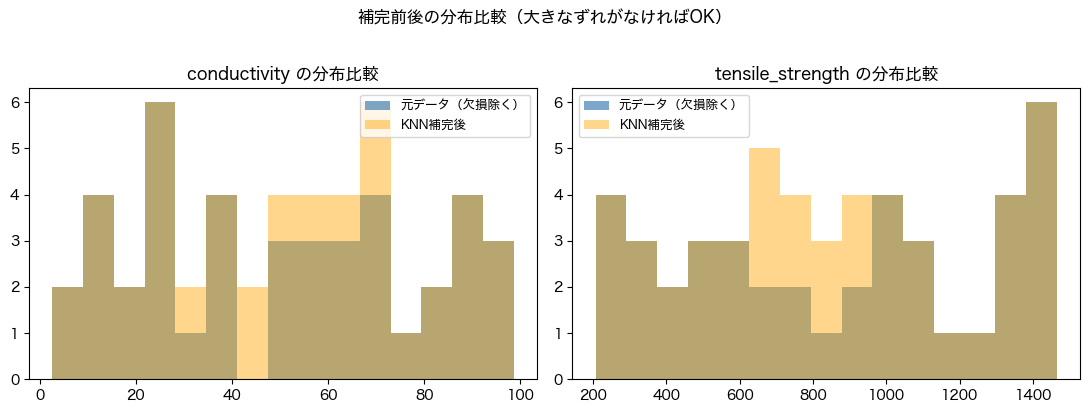

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col in zip(axes, ['conductivity', 'tensile_strength']):
    ax.hist(df[col].dropna(), bins=15, alpha=0.7, label='元データ（欠損除く）', color='steelblue')
    ax.hist(df_imputed[col], bins=15, alpha=0.45, label='KNN補完後', color='orange')
    ax.set_title(f'{col} の分布比較')
    ax.legend(fontsize=9)

plt.suptitle('補完前後の分布比較（大きなずれがなければOK）', y=1.02)
plt.tight_layout()
plt.show()

### 1-4. 構造的ゼロと真の欠損の分離（配合データ）

配合・処方データで起きる特有の問題。  
材料A・B・C の使用量をそれぞれ列として持つと、使わなかった材料のセルが NaN になる。  
これは「値が不明」ではなく「使っていないので 0」——これを**構造的ゼロ**という。

**なぜ区別が重要か：**  
KNN や MICE をそのまま適用すると「近い実験では材料B を少量使っている」という相関から微小な非ゼロ値が埋め込まれ、  
「実際には使っていない材料がわずかに入っている」という物理的に誤ったデータが生成されてしまう。

**対処の順序：**  
① ドメイン知識で「使っていない材料」を特定して 0 で確定させる  
② 残った NaN（真の欠損 = 使ったが量が記録されていない）にのみ補完アルゴリズムを適用する

In [5]:
# 配合データのサンプル
df_formulation = pd.DataFrame({
    '実験':     ['実験1', '実験2', '実験3', '実験4', '実験5'],
    '材料A_量': [50.0,    np.nan,  60.0,   np.nan,  40.0],
    '材料B_量': [np.nan,  40.0,    np.nan,  35.0,   np.nan],
    '材料C_量': [30.0,    20.0,    np.nan,  25.0,   np.nan],
})

print("元データ（NaN が混在）:")
print(df_formulation.to_string(index=False))

# ドメイン知識：各実験で「使った材料」を定義
used_materials = {
    '実験1': ['材料A_量', '材料C_量'],
    '実験2': ['材料B_量', '材料C_量'],
    '実験3': ['材料A_量'],
    '実験4': ['材料B_量', '材料C_量'],
    '実験5': ['材料A_量'],
}

df_form = df_formulation.set_index('実験').copy()
all_material_cols = ['材料A_量', '材料B_量', '材料C_量']

# Step1: 構造的ゼロを先に 0 で確定
for exp, used_cols in used_materials.items():
    unused_cols = [c for c in all_material_cols if c not in used_cols]
    df_form.loc[exp, unused_cols] = 0.0

print("\n構造的ゼロを 0 で確定した後：")
print(df_form)
print("\n残った NaN = 真の欠損（使ったが量が未記録）:")
print(df_form.isnull().sum())
print("\n→ 残った NaN のみに補完アルゴリズムを適用する")

元データ（NaN が混在）:
 実験  材料A_量  材料B_量  材料C_量
実験1   50.0    NaN   30.0
実験2    NaN   40.0   20.0
実験3   60.0    NaN    NaN
実験4    NaN   35.0   25.0
実験5   40.0    NaN    NaN

構造的ゼロを 0 で確定した後：
     材料A_量  材料B_量  材料C_量
実験                      
実験1   50.0    0.0   30.0
実験2    0.0   40.0   20.0
実験3   60.0    0.0    0.0
実験4    0.0   35.0   25.0
実験5   40.0    0.0    0.0

残った NaN = 真の欠損（使ったが量が未記録）:
材料A_量    0
材料B_量    0
材料C_量    0
dtype: int64

→ 残った NaN のみに補完アルゴリズムを適用する


---
## 2. 外れ値の検出と対処

材料科学で外れ値には2種類ある。

| 種類 | 内容 | 対処 |
|------|------|------|
| **実験ミス・ノイズ** | 機器の誤動作、転記ミス、コンタミネーション | 除外または修正 |
| **真の特異挙動** | 新材料の発見、予想外の反応性 | 保持して詳細調査 |

統計アルゴリズムは「統計的に異常なサンプル」を検出するだけであり、どちらの種類かの判断はドメイン知識が必要。  
**外れ値の検出は自動化できても、その解釈は人間が行う。**

検出後の対処は4択：①除外 ②Winsorization（クリッピング） ③ロバスト回帰 ④そのまま使う

### 2-1. 分布の目視確認（箱ひげ図）

外れ値検出の最初のステップは目視確認。箱ひげ図でヒゲの外に出るサンプルを把握する。  
「明らかにおかしい値」（物理的にありえない値など）はここで特定できる。

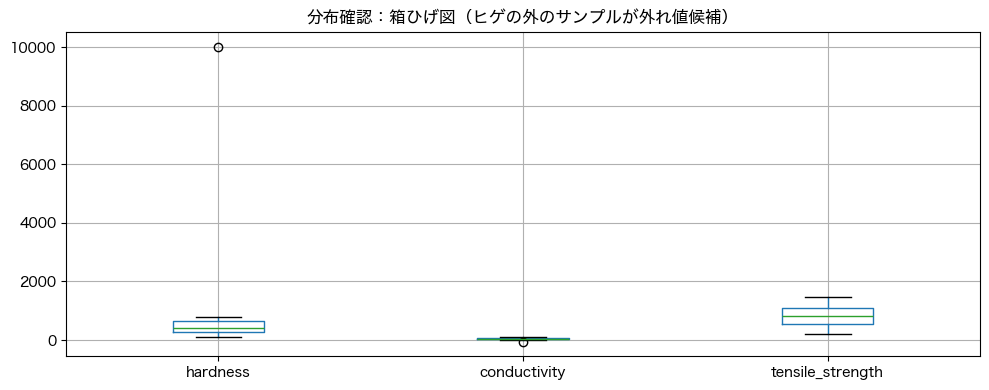

物理的に明らかな外れ値:
   hardness
2    9999.0
   conductivity
7         -50.0


In [6]:
# 外れ値を人工的に追加（実験ミスを再現）
df_outlier = df_imputed.copy()
df_outlier.loc[2, 'hardness'] = 9999    # 硬度として明らかに異常な値
df_outlier.loc[7, 'conductivity'] = -50 # 導電率は負になりえない

df_outlier[['hardness', 'conductivity', 'tensile_strength']].boxplot(figsize=(10, 4))
plt.title('分布確認：箱ひげ図（ヒゲの外のサンプルが外れ値候補）')
plt.tight_layout()
plt.show()

print("物理的に明らかな外れ値:")
print(df_outlier[df_outlier['hardness'] > 2000][['hardness']])
print(df_outlier[df_outlier['conductivity'] < 0][['conductivity']])

### 2-2. Isolation Forest による多変量異常検知

1変数ずつの箱ひげ図では見つけにくい「複数の特徴量の組み合わせとして異常なサンプル」を検出する。  

**Isolation Forest の仕組み：**  
空間をランダムに分割する決定木を繰り返し構築し、少ない分割回数で孤立するサンプルを外れ値と判定する。  
高次元データでも計算コストが低く、化学記述子が数十〜数百に及ぶデータに有効。

**`contamination` パラメータ：** データ全体の何割が外れ値かの事前推定値。小データでは 0.05（5%）程度から始める。

In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

# スケーリング（外れ値の影響を受けにくい RobustScaler を使用）
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_outlier[['hardness', 'conductivity', 'tensile_strength',
                                             'composition_A', 'temperature_K']])

# Isolation Forest で異常スコアを計算
clf = IsolationForest(contamination=0.05, random_state=42)
outlier_labels = clf.fit_predict(X_scaled)   # -1: 外れ値, 1: 正常
outlier_scores = clf.decision_function(X_scaled)  # スコアが低いほど外れ値

df_outlier['IF_label'] = outlier_labels
df_outlier['IF_score'] = outlier_scores

outliers = df_outlier[outlier_labels == -1]
print(f"検出された外れ値: {len(outliers)} 件")
print("\n外れ値として検出されたサンプル（スコアが低いほど異常度が高い）:")
print(outliers[['hardness', 'conductivity', 'tensile_strength', 'IF_score']].sort_values('IF_score'))
print("\n→ これらをドメイン専門家に提示し、実験ミスか真の特異挙動かを確認する")

検出された外れ値: 3 件

外れ値として検出されたサンプル（スコアが低いほど異常度が高い）:
       hardness  conductivity  tensile_strength  IF_score
2   9999.000000     15.344592        410.117328 -0.131535
7    628.885797    -50.000000       1062.552300 -0.048173
48   136.035126     88.821556       1452.705970 -0.008022

→ これらをドメイン専門家に提示し、実験ミスか真の特異挙動かを確認する


### 2-3. Winsorization（データ数を減らさずに外れ値を抑制）

小データで外れ値を「削除」すると貴重なサンプルを失う。  
**Winsorization** は外れ値を削除せず、分布の上下数パーセンタイルの値でクリッピング（置き換え）する。  
データ数（N）を維持したまま、極端な値による平均・分散の歪みを防げる。

例：IQR法（fold=1.5）の場合 → [Q1 − 1.5×IQR, Q3 + 1.5×IQR] の範囲外をそれぞれ境界値で置換

In [8]:
feature_cols = ['hardness', 'conductivity', 'tensile_strength']

try:
    from feature_engine.outliers import Winsorizer
    winsorizer = Winsorizer(capping_method='iqr', tail='both', fold=1.5,
                            variables=feature_cols)
    df_winsorized = winsorizer.fit_transform(df_outlier[feature_cols].copy())
    print("feature-engine による Winsorization 完了")
except ImportError:
    print("feature-engine 未インストール → scipy で代替")
    from scipy.stats.mstats import winsorize
    df_winsorized = df_outlier[feature_cols].copy()
    for col in feature_cols:
        df_winsorized[col] = winsorize(df_winsorized[col].values, limits=[0.05, 0.05])

# 処理前後の比較
print("\n処理前後の最大値比較（外れ値が抑制されているか確認）:")
comparison = pd.DataFrame({
    '処理前_max': df_outlier[feature_cols].max(),
    '処理後_max': df_winsorized[feature_cols].max(),
    '処理前_min': df_outlier[feature_cols].min(),
    '処理後_min': df_winsorized[feature_cols].min(),
})
print(comparison)

feature-engine による Winsorization 完了

処理前後の最大値比較（外れ値が抑制されているか確認）:
                      処理前_max      処理後_max     処理前_min     処理後_min
hardness          9999.000000  1248.961254  104.866491  104.866491
conductivity        98.579395    98.579395  -50.000000  -41.236766
tensile_strength  1464.913721  1464.913721  206.580059  206.580059


### 2-4. ロバスト回帰（外れ値に強いモデル）

前処理で外れ値を除去するのではなく、モデル自体に外れ値への耐性を持たせるアプローチ。

| モデル | 特徴 |
|--------|------|
| **LinearRegression** | 二乗誤差を最小化。外れ値を1点でも強く引っ張られる |
| **HuberRegressor** | 誤差が小さいときは二乗損失、大きいときは絶対値損失。外れ値の影響を緩和 |
| **RANSACRegressor** | ランダム抽出したサブセットでモデルを繰り返し構築し、外れ値を除外したインライアでフィット |

RMSE を比較して、外れ値への耐性の違いを確認する。

In [9]:
from sklearn.linear_model import LinearRegression, HuberRegressor, RANSACRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

X = df_outlier[['composition_A', 'temperature_K']].values
y = df_outlier['hardness'].values  # 外れ値 9999 を含む

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("各モデルの RMSE 比較（外れ値 9999 が訓練データに含まれる）:")
for name, model in [
    ('LinearRegression（外れ値に弱い）', LinearRegression()),
    ('HuberRegressor  （外れ値を緩和）', HuberRegressor(epsilon=1.35)),
    ('RANSACRegressor （外れ値を排除）', RANSACRegressor(random_state=42)),
]:
    model.fit(X_train, y_train)
    rmse = root_mean_squared_error(y_test, model.predict(X_test))
    print(f"  {name}: RMSE = {rmse:.1f}")

各モデルの RMSE 比較（外れ値 9999 が訓練データに含まれる）:


TypeError: got an unexpected keyword argument 'squared'

---
## 3. 単位・表記の不統一

複数の実験室・論文・データベースからデータを統合すると、単位や表記が揃っていないことが常態化する。  
機械学習モデルは単位の違いを区別できないため、前処理で統一する必要がある。

**よくあるパターン：**
- 温度が ℃ と K で混在
- 圧力が Pa、atm、Torr で入り乱れる
- 同じ分子でも SMILES 表記が異なる
- 組成文字列（Ni0.8Co0.15Al0.05O2）が 1 セルに入っており特徴量として展開されていない

### 3-1. Pint による単位変換の自動化

**Pint** は数値と単位をセットで扱うライブラリ。単位間の変換を自動で行い、換算係数の入力ミスを防ぐ。  
例えば ℃ → K の変換（+273.15）を手書きで行う場合のタイプミスをなくせる。

In [ ]:
# pip install pint pint-pandas
try:
    from pint import UnitRegistry
    ureg = UnitRegistry()

    print("=== Pint による単位変換 ===")

    # 温度：℃ → K（オフセット単位は Quantity で指定）
    temp_C = ureg.Quantity(25, 'degC')
    print(f"温度: {temp_C} = {temp_C.to('kelvin'):.2f}")

    # 圧力：Pa → atm
    pressure_Pa = 101325 * ureg.pascal
    print(f"圧力: {pressure_Pa} = {pressure_Pa.to('atm'):.4f}")

    # 長さ：nm → μm
    size_nm = 500 * ureg.nanometer
    print(f"長さ: {size_nm} = {size_nm.to('micrometer')}")

    # エネルギー：eV → J
    energy_eV = 1.0 * ureg.eV
    print(f"エネルギー: {energy_eV} = {energy_eV.to('joule'):.4e}")

except ImportError:
    print("Pint 未インストール。以下でインストール: pip install pint pint-pandas")

### 3-2. スケーラーの比較（StandardScaler / MinMaxScaler / RobustScaler）

単位を揃えた後、SVM・ニューラルネットワーク・KNN などの距離ベースモデルを使う場合はスケーリングが必要。  
**外れ値が存在する小データでは RobustScaler が最適。**

| スケーラー | 外れ値への耐性 | 仕組み |
|-----------|--------------|--------|
| StandardScaler | 弱い | 平均と標準偏差を使う（外れ値が両方を歪める） |
| MinMaxScaler | 最も弱い | 最大・最小値を使う（外れ値が1つで全体が圧縮される） |
| **RobustScaler** | **強い** | 中央値と IQR を使う（外れ値の影響を受けにくい） |

hardness に 9999 という外れ値を入れた状態で比較し、各スケーラーの挙動の違いを確認する。

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

X_raw = df_outlier[['hardness', 'conductivity', 'tensile_strength']].copy()
# hardness に外れ値 9999 が含まれている

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, scaler) in zip(axes, [
    ('StandardScaler', StandardScaler()),
    ('MinMaxScaler',   MinMaxScaler()),
    ('RobustScaler',   RobustScaler()),
]):
    scaled = scaler.fit_transform(X_raw)
    df_s = pd.DataFrame(scaled, columns=X_raw.columns)
    df_s.boxplot(ax=ax)
    ax.set_title(name)
    ax.set_ylim(-2, 5)  # 外れ値を除いた正常値の範囲を見やすくする

plt.suptitle('外れ値（hardness=9999）がある場合のスケーリング比較\n'
             '（MinMaxScaler は正常値が 0 付近に圧縮される）', y=1.03)
plt.tight_layout()
plt.show()

print("hardness のスケーリング後の正常値の分布（5〜95パーセンタイル）:")
for name, scaler in [('StandardScaler', StandardScaler()),
                      ('MinMaxScaler',   MinMaxScaler()),
                      ('RobustScaler',   RobustScaler())]:
    scaled = scaler.fit_transform(X_raw)
    vals = scaled[:, 0]
    vals_normal = vals[vals < np.percentile(vals, 99)]  # 外れ値を除いた値
    print(f"  {name}: {np.percentile(vals_normal, 5):.2f} 〜 {np.percentile(vals_normal, 95):.2f}")

### 3-3. 組成データの CLR 変換（閉包問題への対処）

合金の組成比率（wt%）や混合物の体積分率など「各成分の合計が常に 100% になるデータ」には特殊な処理が必要。

**閉包問題（Closure Problem）とは：**  
「成分 A が増えれば必然的に他の成分が減る」という制約があるため、成分間に偽の負の相関が生まれる。  
この状態でそのまま機械学習を適用すると、モデルが擬似相関を学習してしまう。

**対処：中心対数比変換（CLR: Centered Log-Ratio）**  
組成データを制約のあるシンプレックス空間から、制約のないユークリッド空間に写像する変換。  
変換後は通常のスケーリングや機械学習アルゴリズムを適用できる。

In [ ]:
def clr_transform(X):
    """
    中心対数比変換（CLR: Centered Log-Ratio）
    組成データ（各行の合計が 1 または 100）に適用して閉包問題を解消する。
    
    Parameters
    ----------
    X : np.ndarray, shape (n_samples, n_components)
        各行の合計が 1 または 100 の組成データ
    
    Returns
    -------
    np.ndarray : CLR 変換後のデータ（合計の制約が解除されたユークリッド空間）
    """
    X = np.where(X == 0, 1e-10, X)  # log(0) を避けるための微小値置換
    log_X = np.log(X)
    geometric_mean = log_X.mean(axis=1, keepdims=True)  # 各サンプルの幾何平均
    return log_X - geometric_mean


# 合金組成データ（Al, Ni, Co, Cr の重量分率、各行の合計 = 1）
composition_data = pd.DataFrame({
    'Al': [0.05, 0.10, 0.15, 0.08, 0.20],
    'Ni': [0.60, 0.55, 0.50, 0.62, 0.45],
    'Co': [0.25, 0.25, 0.25, 0.20, 0.25],
    'Cr': [0.10, 0.10, 0.10, 0.10, 0.10],
})

print("元の組成データ（各行の合計 = 1）:")
print(composition_data)
print(f"行合計: {composition_data.sum(axis=1).values}")

# CLR 変換
X_clr = clr_transform(composition_data.values)
df_clr = pd.DataFrame(X_clr, columns=composition_data.columns)
print("\nCLR 変換後（合計の制約が解除されたユークリッド空間）:")
print(df_clr.round(4))

In [ ]:
# CLR 変換前後の相関行列を可視化して、擬似相関の解消を確認
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(composition_data.corr(), annot=True, fmt='.2f', ax=axes[0],
            vmin=-1, vmax=1, cmap='RdBu_r')
axes[0].set_title('CLR 変換前\n（閉包問題により成分間に擬似的な負の相関が生じる）')

sns.heatmap(df_clr.corr(), annot=True, fmt='.2f', ax=axes[1],
            vmin=-1, vmax=1, cmap='RdBu_r')
axes[1].set_title('CLR 変換後\n（擬似相関が解消され、真の相関構造が見えやすくなる）')

plt.tight_layout()
plt.show()
print("\n→ 変換前は全成分が負の相関を持ちがちだが、変換後は相関の強弱が分離される")

---
## まとめ

| 問題 | 自動化できること | 人間の判断が必要なこと |
|------|----------------|---------------------|
| 欠損値（測定値） | KNN / MissForest / MatImpute による補完 | BDL か実験失敗か。欠損自体に意味があるか |
| 欠損値（条件変数） | 欠損フラグの生成 | 標準条件の推定。列を残すか除外するか |
| 欠損値（配合・構造的ゼロ） | 補完後の残 NaN への imputation | どの材料を「使っていない（=0）」と確定できるか |
| 外れ値 | Isolation Forest / LOF による異常スコア算出 | 実験ミスか真の特異挙動か |
| 単位不統一 | Pint による自動変換、RDKit による構造標準化 | データ辞書の設計（何を正とするか） |

機械的に処理できる工程は自動化して、判断が必要な工程に時間を使う。  
材料科学では「データを知っている人が前処理に関わること」がモデルの品質を決める。

---

## 未確認・要検証

- [ ] MatImpute の実行確認（GitHub: [big-material/MatImpute](https://github.com/big-material/MatImpute)）
- [ ] RDKit SMILES 標準化コードを実データで確認
- [ ] BDL 補完（QRILC）の実行確認
- [ ] pint-pandas と DataFrame 連携の確認
- [ ] CLR 変換前後で回帰精度を比較（実データで）